In [1]:
import numpy as np
import os
import torch
from torch.utils.data import DataLoader
from matplotlib import pyplot as plt
from accelerate import Accelerator
from torch_ema import ExponentialMovingAverage as EMA
from torchvision import transforms as tf
import torch.distributed as dist

from wavediffusion.model_unet import myUnet
from wavediffusion.model import Scaled
from wavediffusion.wavedata import npyDataWndHist
from wavediffusion.diffusion import ScheduleLogLinear, ScheduleDDPM, samples, masked_training_loop

from wavediffusion.waveutils import evaluate, sample_and_save

%load_ext autoreload
%autoreload 2

In [2]:
train_file_path = '/global/homes/j/jiarongw/scratch_folder/wave_data/train_global/'
train_file_names = [
    *( (f'wave_2010{i:02d}', f'forcing_2010{i:02d}') for i in range(1, 13) ),
    *( (f'wave_2011{i:02d}', f'forcing_2011{i:02d}') for i in range(1, 13) ),
    *( (f'wave_2012{i:02d}', f'forcing_2012{i:02d}') for i in range(1, 13) ),
    *( (f'wave_2013{i:02d}', f'forcing_2013{i:02d}') for i in range(1, 13) ),
    *( (f'wave_2014{i:02d}', f'forcing_2014{i:02d}') for i in range(1, 13) ),
    *( (f'wave_2015{i:02d}', f'forcing_2015{i:02d}') for i in range(1, 13) ),
    *( (f'wave_2016{i:02d}', f'forcing_2016{i:02d}') for i in range(1, 13) ),
    *( (f'wave_2017{i:02d}', f'forcing_2017{i:02d}') for i in range(1, 13) ),
    *( (f'wave_2018{i:02d}', f'forcing_2018{i:02d}') for i in range(1, 13) ),
    *( (f'wave_2019{i:02d}', f'forcing_2019{i:02d}') for i in range(1, 13) ),
    *( (f'wave_2020{i:02d}', f'forcing_2020{i:02d}') for i in range(1, 13) ),
    *( (f'wave_2021{i:02d}', f'forcing_2021{i:02d}') for i in range(1, 13) ),
    *( (f'wave_2022{i:02d}', f'forcing_2022{i:02d}') for i in range(1, 13) ),
]
train_file_list = [(os.path.join(train_file_path, f'{x}.npy'), 
                    os.path.join(train_file_path, f'{f}.npy')) for x, f in train_file_names]   
stats_file = os.path.join(train_file_path, 'stats.npz')
stats = np.load(stats_file)
meanx, stdx = stats['meanx'], stats['stdx']
meanf, stdf = stats['meanf'], stats['stdf']
train = npyDataWndHist(
    train_file_list,
    resize_x=(320,320), resize_f=(320,320), 
    landmaskname=os.path.join(train_file_path, 'mask.npy'),
    use_icymask=True, compute_stats=False,
    meanx=meanx, stdx=stdx, meanf=meanf, stdf=stdf
)

In [3]:
loader = DataLoader(train, batch_size=4, shuffle=True)
loader_iter = iter(loader)
x, f, mask = next(loader_iter)

/global/u1/j/jiarongw/wavediffusion/src/wavediffusion/wavedata.py:373: UserWarning: The given NumPy array is not writable, and PyTorch does not support non-writable tensors. This means writing to this tensor will result in undefined behavior. You may want to copy the array to protect its data or make it writable before converting it to a tensor. This type of warning will be suppressed for the rest of this program. (Triggered internally at /mscratch/sd/s/swowner/pytorch-build/pytorch/2.6.0/pytorch/torch/csrc/utils/tensor_numpy.cpp:203.)
  f = torch.from_numpy(self.F_files[file_idx][local_idx]).float()


In [4]:
x.shape

torch.Size([4, 4, 320, 320])

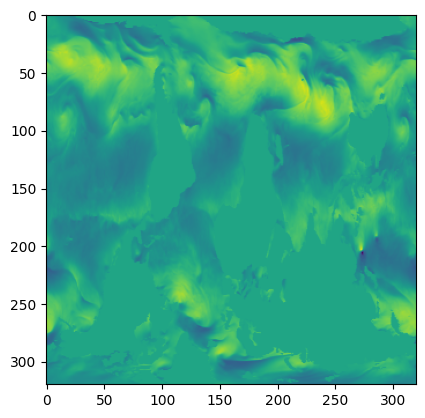

In [8]:
from matplotlib import pyplot as plt
plt.imshow(f[0,5])